NPZ detected. Time='c001_Time', 16 voltage columns; plotting indices: [0, 1, 2, 3, 4]


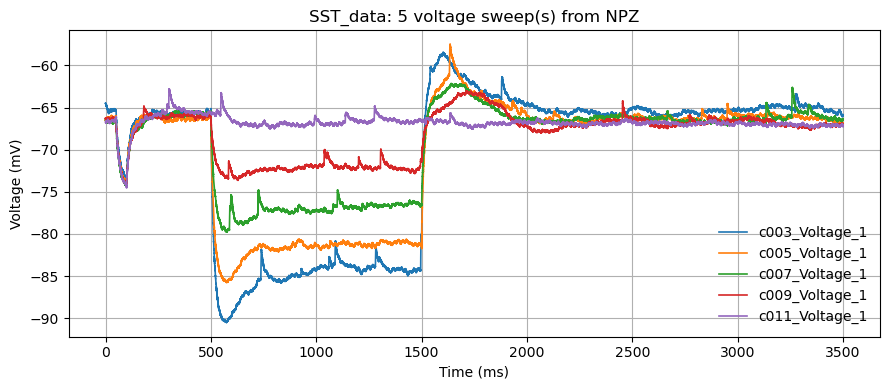

In [1]:
# Self-contained plotting cell for the inspected SST_data dataset
# - Priority: NPZ > CSV > PKL (fastest & cleanest first)
# - Time shown in ms; Voltage in mV; optional Current in pA on a 2nd axis
# - SWEEP_IDX supports: None | int | [i,j,...] | (start,end) inclusive range

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

# ---- user-tweakable ----
DS_DIR       = "/home/hrbncv/PV-SST/single_cells/Madhu_Data/MAT_Analysis/processed/SST_data"
STEM         = "SST_data"
SWEEP_IDX    = (0,4)          # None | int | [i,j,...] | (start,end) inclusive
PLOT_CURRENT = True          # If True and a single sweep is chosen, overlay current (pA) on right y-axis
MAX_OVERLAY  = 5             # Max sweeps to overlay when SWEEP_IDX=None
STRIDE       = 1             # Downsample stride for plotting (e.g., 5 plots every 5th point)

CSV_FP = f"{DS_DIR}/{STEM}.csv"
NPZ_FP = f"{DS_DIR}/{STEM}.npz"
PKL_FP = f"{DS_DIR}/{STEM}.pkl"

def _normalize_indices(n, want, k_auto=5):
    if n <= 0: return []
    if want is None:
        k = min(k_auto, n)
        return np.unique(np.linspace(0, n-1, k, dtype=int)).tolist()
    if isinstance(want, (list, tuple)):
        # treat (start,end) as inclusive range
        if len(want) == 2 and all(isinstance(x, (int, np.integer)) for x in want):
            a, b = int(want[0]), int(want[1])
            if a < 0: a += n
            if b < 0: b += n
            a = max(0, min(n-1, a)); b = max(0, min(n-1, b))
            step = 1 if a <= b else -1
            return list(range(a, b + step, step))
        # else explicit list
        out = []
        for x in want:
            if isinstance(x, (int, np.integer)):
                if x < 0: x += n
                if 0 <= x < n: out.append(int(x))
        return sorted(set(out))
    if isinstance(want, (int, np.integer)):
        x = int(want)
        if x < 0: x += n
        return [x] if 0 <= x < n else [0]
    return [0]

def _num_prefix(s):
    # Extract the number after leading 'c' in keys like 'c003_Voltage_1'
    try:
        if isinstance(s, str) and s.startswith("c") and "_" in s:
            return int(s[1:s.index("_")])
    except Exception:
        pass
    return None

def _sort_keys_nat(keys, contains):
    ks = [k for k in keys if isinstance(k, str) and contains.lower() in k.lower()]
    ks_with_num = [(k, _num_prefix(k)) for k in ks]
    ks_with_num.sort(key=lambda x: (999999 if x[1] is None else x[1], x[0]))
    return [k for k,_ in ks_with_num]

def _pair_current_for_voltage(vkey, all_keys):
    # Map 'cXYZ_Voltage_1' -> 'c{XYZ-1:03d}_Current_1' if present
    if not isinstance(vkey, str): return None
    try:
        head, tail = vkey.split("_", 1)     # 'c003', 'Voltage_1'
        num = int(head[1:])
        suffix = tail.split("_", 1)[-1]     # '1'
        cand = f"c{num-1:03d}_Current_{suffix}"
        return cand if cand in all_keys else None
    except Exception:
        return None

def _plot_traces(t_ms, volts_mV, labels, title, current_pA=None, current_label=None):
    t_ms = t_ms[::STRIDE]
    plt.figure(figsize=(9,4))
    for y, lab in zip(volts_mV, labels):
        plt.plot(t_ms, y[::STRIDE], lw=1.2, label=lab)
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.title(title)
    if len(labels) > 1: plt.legend(loc="best", frameon=False)
    ax = plt.gca()
    if current_pA is not None:
        ax2 = ax.twinx()
        ax2.plot(t_ms, current_pA[::STRIDE], lw=1.0, alpha=0.7)
        ax2.set_ylabel("Current (pA)")
        if current_label:
            ax2.set_title(current_label, fontsize=9, loc="right", pad=12)
    plt.grid(True); plt.tight_layout(); plt.show()

used = False

# ---- 1) NPZ path (fastest/cleanest here) ----
try:
    with np.load(NPZ_FP) as z:
        keys = list(z.files)
        if keys:
            # time in seconds
            tkey = next((k for k in keys if k.lower() in ("c001_time","time","t","c001_time")), None)
            if tkey is None:
                # fallback: first key containing "time"
                tkey = next((k for k in keys if "time" in k.lower()), None)
            if tkey is not None:
                t = np.asarray(z[tkey]).astype(float).ravel()
                t_ms = t * 1e3
                vkeys = _sort_keys_nat(keys, "Voltage")
                if vkeys:
                    n = len(vkeys)
                    idx = _normalize_indices(n, SWEEP_IDX, k_auto=min(MAX_OVERLAY, n))
                    chosen_vkeys = [vkeys[i] for i in idx if 0 <= i < n]
                    Y_mV = [np.asarray(z[k]).astype(float).ravel()*1e3 for k in chosen_vkeys]
                    title = f"{STEM}: {len(chosen_vkeys)} voltage sweep(s) from NPZ"
                    # optional paired current overlay if exactly one sweep selected
                    cur_pA = None; cur_label = None
                    if PLOT_CURRENT and len(chosen_vkeys) == 1:
                        ckey = _pair_current_for_voltage(chosen_vkeys[0], keys)
                        if ckey is not None:
                            cur_pA = np.asarray(z[ckey]).astype(float).ravel()*1e12
                            cur_label = f"{ckey} (pA)"
                    print(f"NPZ detected. Time='{tkey}', {n} voltage columns; plotting indices: {idx}")
                    _plot_traces(t_ms, Y_mV, chosen_vkeys, title, current_pA=cur_pA, current_label=cur_label)
                    used = True
except Exception as e:
    # fall through to CSV/PKL
    pass

# ---- 2) CSV fallback ----
if not used:
    try:
        df = pd.read_csv(CSV_FP)
        # time in seconds
        tcol = None
        for cand in ("c001_Time","Time","time","t","c001_time"):
            if cand in df.columns: tcol = cand; break
        if tcol is None:
            tcol = next((c for c in df.columns if "time" in c.lower()), None)
        if tcol is not None:
            t_ms = df[tcol].astype(float).to_numpy().ravel()*1e3
            vcols = [c for c in df.columns if "voltage" in c.lower()]
            # natural-sort by numeric prefix
            vcols = sorted(vcols, key=lambda k: (_num_prefix(k) if _num_prefix(k) is not None else 999999, k))
            if vcols:
                n = len(vcols)
                idx = _normalize_indices(n, SWEEP_IDX, k_auto=min(MAX_OVERLAY, n))
                chosen = [vcols[i] for i in idx if 0 <= i < n]
                Y_mV = [df[c].astype(float).to_numpy().ravel()*1e3 for c in chosen]
                cur_pA = None; cur_label = None
                if PLOT_CURRENT and len(chosen) == 1:
                    ckey = _pair_current_for_voltage(chosen[0], df.columns)
                    if ckey is not None:
                        cur_pA = df[ckey].astype(float).to_numpy().ravel()*1e12
                        cur_label = f"{ckey} (pA)"
                print(f"CSV detected. Time='{tcol}', {n} voltage columns; plotting indices: {idx}")
                _plot_traces(t_ms, Y_mV, chosen, f"{STEM}: {len(chosen)} voltage sweep(s) from CSV",
                             current_pA=cur_pA, current_label=cur_label)
                used = True
    except Exception:
        pass

# ---- 3) PKL fallback (sanitizing odd keys) ----
if not used:
    try:
        with open(PKL_FP, "rb") as f:
            obj = pickle.load(f)
        # sanitize keys by stripping at first null char
        if isinstance(obj, dict):
            clean = {}
            for k, v in obj.items():
                kk = k.split("\x00", 1)[0] if isinstance(k, str) else k
                clean[kk] = v
        else:
            clean = obj
        keys = list(clean.keys()) if isinstance(clean, dict) else []
        # find time
        tkey = None
        for cand in ("c001_Time","Time","time","t","c001_time"):
            if cand in keys: tkey = cand; break
        if tkey is None:
            tkey = next((k for k in keys if isinstance(k, str) and "time" in k.lower()), None)
        if tkey is None:
            raise ValueError("No time key found in PKL.")
        t_ms = np.asarray(clean[tkey]).astype(float).ravel()*1e3
        vkeys = _sort_keys_nat(keys, "Voltage")
        if not vkeys:
            raise ValueError("No voltage keys found in PKL.")
        n = len(vkeys)
        idx = _normalize_indices(n, SWEEP_IDX, k_auto=min(MAX_OVERLAY, n))
        chosen_v = [vkeys[i] for i in idx if 0 <= i < n]
        Y_mV = [np.asarray(clean[k]).astype(float).ravel()*1e3 for k in chosen_v]
        cur_pA = None; cur_label = None
        if PLOT_CURRENT and len(chosen_v) == 1:
            ckey = _pair_current_for_voltage(chosen_v[0], keys)
            if ckey is not None:
                cur_pA = np.asarray(clean[ckey]).astype(float).ravel()*1e12
                cur_label = f"{ckey} (pA)"
        print(f"PKL detected (sanitized keys). Time='{tkey}', {n} voltage columns; plotting indices: {idx}")
        _plot_traces(t_ms, Y_mV, chosen_v, f"{STEM}: {len(chosen_v)} voltage sweep(s) from PKL",
                     current_pA=cur_pA, current_label=cur_label)
        used = True
    except Exception as e:
        print("[error] PKL load/plot failed:", e)

if not used:
    print("No plottable time-series detected. Check for a time column/array and voltage arrays in NPZ/CSV/PKL.")
